In [ ]:
import cfe
import scanpy as sc

cfe.settings.backend = "python_function"
cfe.logger.setLevel("INFO")

[2025年04月27日 11时53分50秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

*** stack smashing detected ***: terminated


数据

In [2]:
# 读取scvelo的pancreas数据
adata = sc.read_h5ad("../tests/data/bifurcating.h5ad")
fadata = cfe.data.FateAnnData.from_anndata(adata)
fadata.layers["expression"] = fadata.layers["spliced"]
fadata.layers["count"] = fadata.layers["spliced"]


fadata.obs.index = [f"cell_{i:03d}" for i in range(fadata.shape[0])]

fadata

AnnData object with n_obs × n_vars = 1000 × 250
    obs: 'cell_id', 'from', 'to', 'time', 'lineage', 'global_time', 'lin_time_sC -> sEndC', 'lin_time_sA -> sB', 'lin_time_sB -> sBmid', 'lin_time_sBmid -> sC', 'lin_time_sD -> sEndD', 'lin_time_sBmid -> sD'
    uns: 'endpoints', 'gt_velocities', 'lineage_colors', 'startpoints', 'cfe'
    obsm: 'X_emb', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

In [3]:
import pandas as pd

# 手动添加参考里程碑
milestone_network = pd.DataFrame(
    data=[
        ["sA -> sB", "sB -> sBmid"],
        ["sB -> sBmid", "sBmid -> sC"],
        ["sB -> sBmid", "sBmid -> sD"],
        ["sBmid -> sC", "sC -> sEndC"],
        ["sBmid -> sD", "sD -> sEndD"],
        ],
    columns=["from", "to"]
)

fadata.add_trajectory_mannually(milestone_network, cluster_key="lineage")

AnnData object with n_obs × n_vars = 1000 × 250
    obs: 'cell_id', 'from', 'to', 'time', 'lineage', 'global_time', 'lin_time_sC -> sEndC', 'lin_time_sA -> sB', 'lin_time_sB -> sBmid', 'lin_time_sBmid -> sC', 'lin_time_sD -> sEndD', 'lin_time_sBmid -> sD', 'milestone_color', 'milestone'
    uns: 'endpoints', 'gt_velocities', 'lineage_colors', 'startpoints', 'cfe', 'milestone_color_dict', 'milestone_colors', 'milestone_color_colors'
    obsm: 'X_emb', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

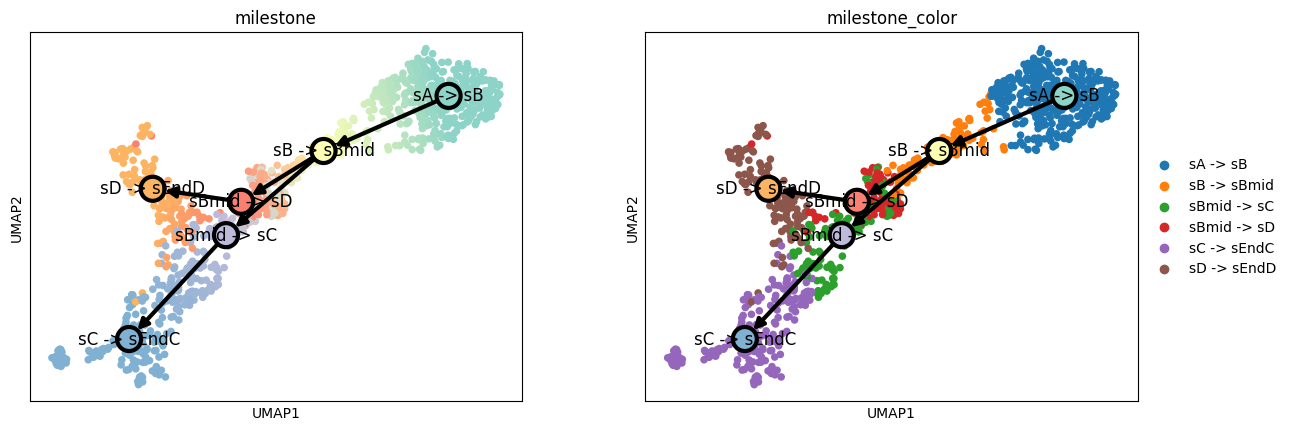

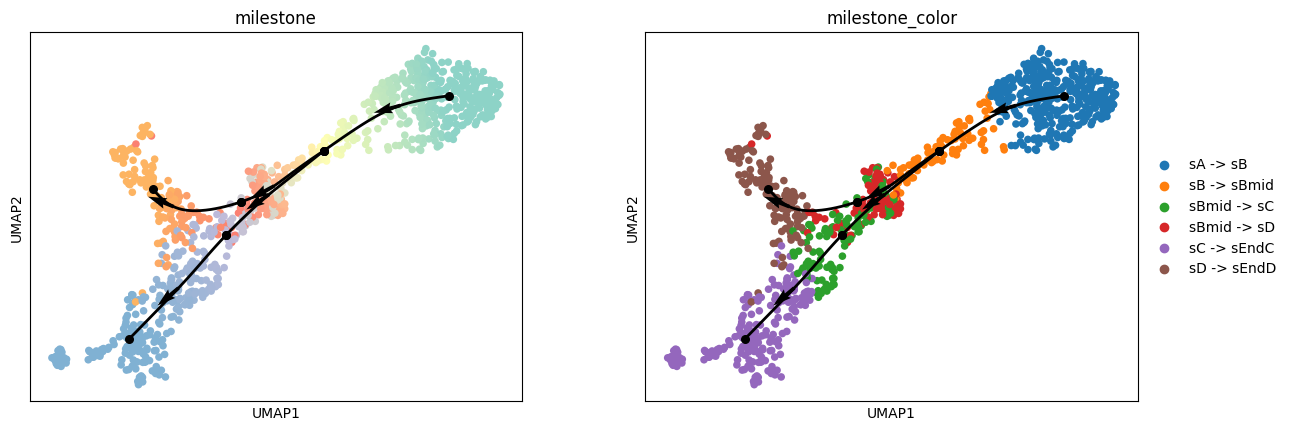

In [4]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key) # new cluster color

basis = "umap"
cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list, curve=False)
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list, curve=True)
fadata

[2025年04月27日 11时54分00秒] INFO     find wrapper type: directed                                                 


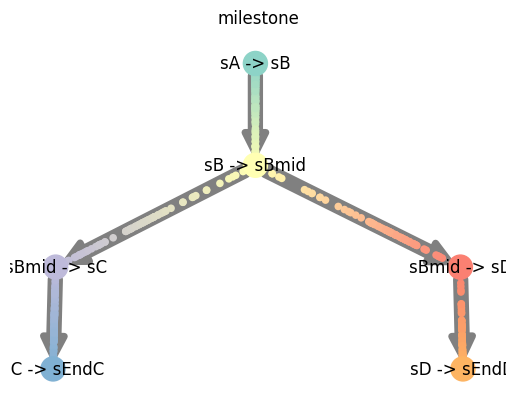

In [5]:
cfe.plot.plot_wrapper(fadata)

[2025年04月27日 11时54分05秒] INFO     Loaded function: <function cf_cellrank at 0x7bfb57b82560> from              
                                       /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/functi
                                       on/cf_cellrank.py                                                           
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x7bfb57f9c9d0>                                                                   
Defaulting to `'gmres'` solver.


  0%|          | 0/2 [00:00<?, ?/s]

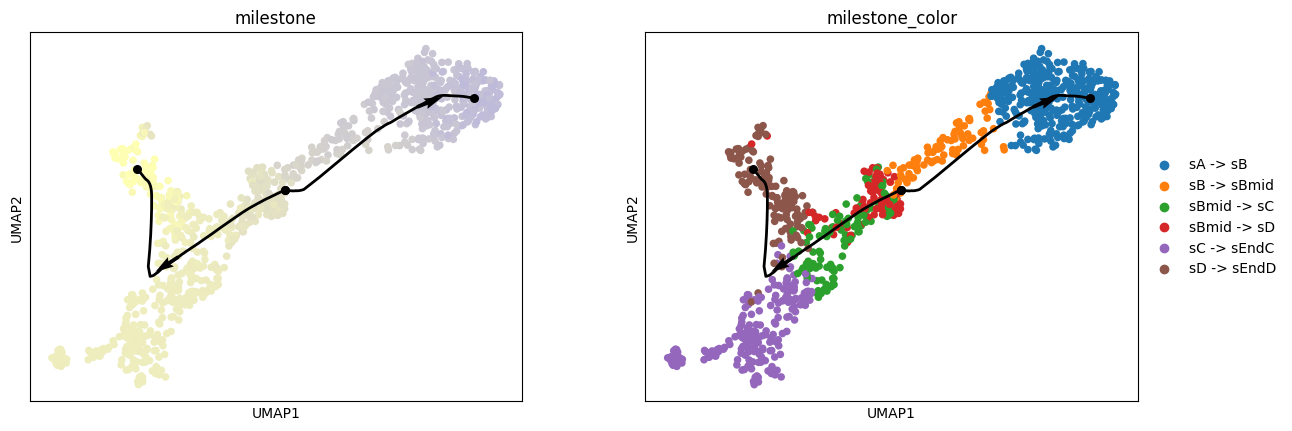

In [6]:
prior_information = {}
# 参数给的特别详细
parameters = {
    "cluster_key":cluster_key,
    "n_states": 6,
    "n_terminal_states": 2,
    # "initial_states": ["sA -> sB"],
    # "terminal_states": ["sC -> sEndC", "sD -> sEndD"],
    "wrapper_type": "probability"
}
fadata.add_prior_information(**prior_information)  # add prior information to fadata

# method_name_list = ["state_comp"]
method_name_list = ["cellrank"]

for method_name in method_name_list:
    method = cfe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata, parameters=parameters)
    cfe.plot.plot_trajectory(fadata, basis="umap", color=cluster_key_list)

In [7]:
parameters["wrapper_type"] = "lineage"
# method_name_list = ["state_comp"]
method_name_list = ["cellrank"]

for method_name in method_name_list:
    method = cfe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata, parameters=parameters)
    cfe.plot.plot_trajectory(fadata, basis="umap", color=cluster_key_list)

[2025年04月27日 11时54分15秒] INFO     Loaded function: <function cf_cellrank at 0x7bfbf8b85a20> from              
                                       /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/functi
                                       on/cf_cellrank.py                                                           
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x7bfb5ebca950>                                                                   


  0%|          | 0/2 [00:00<?, ?/s]

cluster_series
cell_000    sC -> sEndC
cell_001       sA -> sB
cell_002    sC -> sEndC
cell_003    sB -> sBmid
cell_004    sBmid -> sC
               ...     
cell_995    sC -> sEndC
cell_996       sA -> sB
cell_997    sC -> sEndC
cell_998       sA -> sB
cell_999    sBmid -> sD
Name: milestone_color, Length: 1000, dtype: category
Categories (6, object): ['sA -> sB', 'sB -> sBmid', 'sBmid -> sC', 'sBmid -> sD', 'sC -> sEndC', 'sD -> sEndD']
cluster_probability
             sD -> sEndD  sA -> sB
cluster                           
sA -> sB        0.126818  0.873172
sB -> sBmid     0.338164  0.661817
sBmid -> sC     0.653243  0.346727
sBmid -> sD     0.599880  0.400094
sC -> sEndC     0.732276  0.267679
sD -> sEndD     0.871299  0.128688
[['sB -> sBmid', 'sBmid -> sD', 'sBmid -> sC', 'sC -> sEndC', 'sD -> sEndD'], ['sC -> sEndC', 'sBmid -> sC', 'sBmid -> sD', 'sB -> sBmid', 'sA -> sB']]


IndexError: list index out of range

In [ ]:
fadata.trajectory_history_dict.keys()

dict_keys(['ref', '20250427_115313__cellrank-python_function__Q04IBrpb5b', '20250427_115322__cellrank-python_function__Lv0HmPTK26'])

In [ ]:
for i in list(fadata.trajectory_history_dict.keys())[::-1]:
    if "__cellrank-python_function__" in i:
        name = i
        break
name

'20250427_115322__cellrank-python_function__Lv0HmPTK26'

In [ ]:
tmp = fadata.trajectory_history_dict[name]["milestone_wrapper"]
tmp.milestone_network

,from,to,length,directed
0,sC -> sEndC,sB -> sBmid,1,True
1,sB -> sBmid,sBmid -> sC,1,True
2,sBmid -> sC,sBmid -> sD,1,True
3,sBmid -> sD,sD -> sEndD,1,True
4,sBmid -> sD,sA -> sB,1,True
